In [ ]:
# ============================================================
# BLOCK 1 — FASTA -> bảng đặc trưng
# ============================================================

import os
import re
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths ----------
TRAIN_FASTA = "Train_dataset.fasta"
VAL_FASTA   = "validation_dataset.fasta"
TEST_FASTA  = "test_dataset.fasta"

OUT_FEATURES_CSV = "features_per_protein.csv"

# ---------- AA tables ----------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
AA_SET  = set(AA_LIST)

SET_HYDROPHOBIC = set("AVILMFWY")
SET_DISORDER    = set("EDKRQSP")

HYDROPATHY_KD = {
    "A": 1.8,  "C": 2.5,  "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5,  "K": -3.9, "L": 3.8,
    "M": 1.9,  "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2,  "W": -0.9, "Y": -1.3,
}

AA_MW = {
    'A': 71.08, 'C': 103.14, 'D': 115.09, 'E': 129.12, 'F': 147.18,
    'G': 57.05, 'H': 137.14, 'I': 113.16, 'K': 128.17, 'L': 113.16,
    'M': 131.19, 'N': 114.10, 'P': 97.12,  'Q': 128.13, 'R': 156.19,
    'S': 87.08, 'T': 101.11, 'V': 99.13,  'W': 186.21, 'Y': 163.18
}
WATER_MASS = 18.015

PKA = {
    'Nterm': 8.0,
    'Cterm': 3.1,
    'C': 8.5,
    'D': 3.9,
    'E': 4.1,
    'H': 6.5,
    'K': 10.8,
    'R': 12.5,
    'Y': 10.1
}

AA_PROPENSITY = {
    'A': [1.42, 0.83, 0.66], 'C': [0.70, 1.19, 1.19], 'D': [1.01, 0.54, 1.46],
    'E': [1.51, 0.37, 0.74], 'F': [1.13, 1.38, 0.60], 'G': [0.57, 0.75, 1.56],
    'H': [1.00, 0.87, 0.95], 'I': [1.08, 1.60, 0.47], 'K': [1.16, 0.74, 1.01],
    'L': [1.21, 1.30, 0.59], 'M': [1.45, 1.05, 0.60], 'N': [0.67, 0.89, 1.56],
    'P': [0.57, 0.55, 1.52], 'Q': [1.11, 1.10, 0.98], 'R': [0.98, 0.93, 0.95],
    'S': [0.77, 0.75, 1.43], 'T': [0.83, 1.19, 0.96], 'V': [1.06, 1.70, 0.50],
    'W': [1.08, 1.37, 0.96], 'Y': [0.69, 1.47, 1.14]
}

# ---------- FASTA I/O ----------
def read_fasta_with_labels(path: str) -> Tuple[List[str], List[str], List[int]]:
    headers, seqs = [], []
    with open(path, "r", encoding="utf-8") as f:
        header, body = None, []
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    headers.append(header)
                    seqs.append("".join(body))
                header = line[1:]
                body = []
            else:
                body.append(line)
        if header is not None:
            headers.append(header)
            seqs.append("".join(body))

    labels = []
    for h in headers:
        m = re.findall(r"(\d+)", h)
        if not m:
            raise ValueError(f"Cannot parse label from header: {h}")
        labels.append(int(m[-1]))
    return headers, seqs, labels

def clean_seq(seq: str) -> str:
    s = re.sub(r"\s+", "", seq).upper()
    return "".join(ch for ch in s if ch in AA_SET)

# ---------- Biochem helpers ----------
def molecular_weight(seq: str) -> float:
    L = len(seq)
    if L == 0:
        return 0.0
    return float(sum(AA_MW[a] for a in seq) - WATER_MASS * (L - 1))

def mean_hydropathy(seq: str) -> float:
    return float(np.mean([HYDROPATHY_KD[a] for a in seq])) if seq else 0.0

def max_hydrophobic_run_ratio(seq: str) -> float:
    L = len(seq)
    if L == 0:
        return 0.0
    max_run = 0
    cur = 0
    for ch in seq:
        if ch in SET_HYDROPHOBIC:
            cur += 1
            max_run = max(max_run, cur)
        else:
            cur = 0
    return float(max_run / L)

def net_charge_at_pH(seq: str, pH: float) -> float:
    counts = {a: 0 for a in AA_LIST}
    for ch in seq:
        counts[ch] += 1

    pos = (
        counts.get('K', 0) / (1.0 + 10.0 ** (pH - PKA['K'])) +
        counts.get('R', 0) / (1.0 + 10.0 ** (pH - PKA['R'])) +
        counts.get('H', 0) / (1.0 + 10.0 ** (pH - PKA['H'])) +
        1.0 / (1.0 + 10.0 ** (pH - PKA['Nterm']))
    )
    neg = (
        counts.get('D', 0) / (1.0 + 10.0 ** (PKA['D'] - pH)) +
        counts.get('E', 0) / (1.0 + 10.0 ** (PKA['E'] - pH)) +
        counts.get('C', 0) / (1.0 + 10.0 ** (PKA['C'] - pH)) +
        counts.get('Y', 0) / (1.0 + 10.0 ** (PKA['Y'] - pH)) +
        1.0 / (1.0 + 10.0 ** (PKA['Cterm'] - pH))
    )
    return float(pos - neg)

def isoelectric_point(seq: str) -> float:
    lo, hi = 0.0, 14.0
    for _ in range(50):
        mid = (lo + hi) / 2.0
        if net_charge_at_pH(seq, mid) > 0:
            lo = mid
        else:
            hi = mid
    return float((lo + hi) / 2.0)

# ---------- Feature extraction (36) ----------
def extract_features(seq: str) -> Dict[str, float]:
    L = len(seq)
    if L == 0:
        return {}

    counts = {aa: 0 for aa in AA_LIST}
    for ch in seq:
        counts[ch] += 1

    feats: Dict[str, float] = {}

    # 20 aa freq
    for aa in AA_LIST:
        feats[f"freq_{aa}"] = counts[aa] / L

    # group ratios
    feats["pos_ratio"]         = (counts["K"] + counts["R"] + counts["H"]) / L
    feats["neg_ratio"]         = (counts["D"] + counts["E"]) / L
    feats["polar_ratio"]       = (counts["S"] + counts["T"] + counts["N"] + counts["Q"]) / L
    feats["hydrophobic_ratio"] = sum(counts[a] for a in SET_HYDROPHOBIC) / L
    feats["tiny_ratio"]        = (counts["G"] + counts["A"]) / L
    feats["sulfur_ratio"]      = (counts["C"] + counts["M"]) / L

    feats["mean_hydropathy"]   = mean_hydropathy(seq)

    # Chou–Fasman mean propensities
    h_sum = sum(AA_PROPENSITY[a][0] * counts[a] for a in AA_LIST)
    s_sum = sum(AA_PROPENSITY[a][1] * counts[a] for a in AA_LIST)
    t_sum = sum(AA_PROPENSITY[a][2] * counts[a] for a in AA_LIST)
    feats["helix_prop_mean"] = h_sum / L
    feats["sheet_prop_mean"] = s_sum / L
    feats["turn_prop_mean"]  = t_sum / L

    feats["disorder_ratio"]    = float(sum(counts[a] for a in SET_DISORDER) / L)
    feats["aggregation_ratio"] = max_hydrophobic_run_ratio(seq)

    feats["molecular_weight"]  = molecular_weight(seq)
    feats["isoelectric_point"] = isoelectric_point(seq)
    feats["net_charge_pH7"]    = net_charge_at_pH(seq, 7.0)

    feats["length"] = float(L)

    return feats

def fasta_to_features_csv(out_csv: str) -> pd.DataFrame:
    all_rows = []
    feature_cols = None

    for split, path in [("train", TRAIN_FASTA), ("val", VAL_FASTA), ("test", TEST_FASTA)]:
        headers, seqs, labels = read_fasta_with_labels(path)

        for h, s, y in zip(headers, seqs, labels):
            sc = clean_seq(s)
            if not sc:
                continue

            feats = extract_features(sc)
            if not feats:
                continue

            if feature_cols is None:
                feature_cols = ["length"] + sorted([k for k in feats.keys() if k != "length"])

            row = {"split": split, "header": h, "label": int(y)}
            for fn in feature_cols:
                row[fn] = float(feats.get(fn, 0.0))
            all_rows.append(row)

    if not all_rows:
        raise ValueError("No valid sequences after cleaning. Check FASTA files / labels / alphabet.")

    df = pd.DataFrame(all_rows)
    df.to_csv(out_csv, index=False)
    return df

df_feat = fasta_to_features_csv(OUT_FEATURES_CSV)
print("Saved:", OUT_FEATURES_CSV, "| rows:", len(df_feat), "| cols:", df_feat.shape[1])
df_feat.head(3)

Saved: features_per_protein_rebuilt.csv | rows: 78031 | cols: 39


,split,header,label,length,aggregation_ratio,disorder_ratio,freq_A,freq_C,freq_D,freq_E,...,mean_hydropathy,molecular_weight,neg_ratio,net_charge_pH7,polar_ratio,pos_ratio,sheet_prop_mean,sulfur_ratio,tiny_ratio,turn_prop_mean
0,train,SeCD00422904_pET21 A-0,0,316.0,0.018987,0.367089,0.113924,0.015823,0.044304,0.063291,...,-0.040823,28478.585,0.107595,-6.053671,0.208861,0.110759,1.009082,0.041139,0.183544,0.942373
1,train,SeCD00422905_pET21 A-0,0,180.0,0.033333,0.338889,0.088889,0.016667,0.066667,0.038889,...,0.071667,16539.275,0.105556,0.031890,0.205556,0.127778,1.035611,0.033333,0.161111,0.941611
2,train,SfCD00344631_pET21 A-0,0,128.0,0.046875,0.382812,0.101562,0.023438,0.078125,0.070312,...,-0.144531,12178.895,0.148438,-4.928648,0.203125,0.117188,1.019297,0.062500,0.132812,0.916797


In [4]:
# ============================================================
# BLOCK 2 — TÓM TẮT DATA
# ============================================================

import pandas as pd

OUT_SUMMARY_GLOBAL = "summary_global.csv"
OUT_SUMMARY_BYCLASS = "summary_by_class.csv"

FEATURE_COLS = [c for c in df_feat.columns if c not in {"split", "header", "label"}]

def summary_table(df: pd.DataFrame, cols):
    x = df[cols].astype(float)
    return pd.DataFrame({
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "min": x.min(),
        "q1": x.quantile(0.25),
        "median": x.median(),
        "q3": x.quantile(0.75),
        "iqr": x.quantile(0.75) - x.quantile(0.25),
        "max": x.max(),
        "missing": x.isna().sum(),
    })

# ---------- Global summary ----------
global_summary = summary_table(df_feat, FEATURE_COLS)
global_summary.to_csv(OUT_SUMMARY_GLOBAL)
print("Saved:", OUT_SUMMARY_GLOBAL)

# ---------- By class summary ----------
summary_pos = summary_table(df_feat[df_feat["label"] == 1], FEATURE_COLS)
summary_pos["class"] = "soluble"

summary_neg = summary_table(df_feat[df_feat["label"] == 0], FEATURE_COLS)
summary_neg["class"] = "insoluble"

summary_byclass = pd.concat([summary_pos, summary_neg])
summary_byclass.to_csv(OUT_SUMMARY_BYCLASS)

print("Saved:", OUT_SUMMARY_BYCLASS)

# Quick check
global_summary.head()

Saved: summary_global.csv
Saved: summary_by_class.csv


,mean,std,min,q1,median,q3,iqr,max,missing
length,294.713832,227.616222,15.0,143.000000,236.000000,374.000000,231.000000,2500.000000,0
aggregation_ratio,0.025111,0.016676,0.0,0.013937,0.020942,0.031646,0.017708,0.466667,0
disorder_ratio,0.402020,0.054415,0.0,0.367647,0.396040,0.429952,0.062305,1.000000,0
freq_A,0.079665,0.039099,0.0,0.052147,0.074126,0.102362,0.050215,0.617347,0
freq_C,0.014815,0.017227,0.0,0.004525,0.011268,0.019950,0.015425,0.370370,0


In [ ]:
# ============================================================
# BLOCK 3A — TÍNH STATS
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score

FEATURE_COLS = [c for c in df_feat.columns if c not in {"split", "header", "label"}]

# ----- speed / CI controls -----
RNG_SEED      = 42
SUBSAMPLE_MAX = 6000
BOOT_HL_B     = 400
BOOT_DELTA_B  = 800

OUT_STATS_CSV = "stats_features.csv"

rng = np.random.default_rng(RNG_SEED)

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    m = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out


def cliffs_delta_from_u(u: float, n1: int, n2: int) -> float:
    # delta = 2U/(n1*n2) - 1  (n1=pos size, n2=neg size)
    return float(2.0 * u / (n1 * n2) - 1.0)


def effect_size_band(delta: float) -> str:
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "medium"
    return "large"


def subsample_pair(pos: np.ndarray, neg: np.ndarray, max_n: int) -> tuple[np.ndarray, np.ndarray]:
    if pos.size > max_n:
        pos = rng.choice(pos, size=max_n, replace=False)
    if neg.size > max_n:
        neg = rng.choice(neg, size=max_n, replace=False)
    return pos, neg


def hl_fast(pos: np.ndarray, neg: np.ndarray) -> float:
    # fast HL proxy used in your code: median(pos) - median(neg)
    return float(np.median(pos) - np.median(neg))


def bootstrap_ci_2sample(func, pos: np.ndarray, neg: np.ndarray, B: int) -> tuple[float, float]:
    n1, n2 = pos.size, neg.size
    stats = np.empty(B, dtype=float)
    for b in range(B):
        p = rng.choice(pos, size=n1, replace=True)
        n = rng.choice(neg, size=n2, replace=True)
        stats[b] = func(p, n)
    return float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))


def roc_best_threshold_youden(scores: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    fpr, tpr, thr = roc_curve(y, scores)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(j[ix])


y = df_feat["label"].astype(int).to_numpy()
if not set(np.unique(y)).issubset({0, 1}):
    raise ValueError("label must be binary {0,1}.")
if (y == 1).sum() == 0 or (y == 0).sum() == 0:
    raise ValueError("Need both classes to compute stats.")

rows = []
pvals = []

for fn in FEATURE_COLS:
    x = df_feat[fn].astype(float).to_numpy()

    pos = x[y == 1]  # soluble
    neg = x[y == 0]  # insoluble

    # MWU
    u, p = mannwhitneyu(pos, neg, alternative="two-sided", method="asymptotic")
    p = float(p)
    pvals.append(p)

    # Cliff's delta
    delta = cliffs_delta_from_u(float(u), int(pos.size), int(neg.size))

    # summaries
    mean_pos, mean_neg = float(np.mean(pos)), float(np.mean(neg))
    med_pos, med_neg = float(np.median(pos)), float(np.median(neg))

    # AUC
    auc = float(roc_auc_score(y, x))

    # Youden J + threshold + balanced acc at that threshold
    thr, jval = roc_best_threshold_youden(x, y)
    bal_acc = float(balanced_accuracy_score(y, (x >= thr).astype(int)))

    # CIs via subsample bootstrap (fast)
    pos_s, neg_s = subsample_pair(pos, neg, SUBSAMPLE_MAX)

    hl = hl_fast(pos_s, neg_s)
    hl_lo, hl_hi = bootstrap_ci_2sample(hl_fast, pos_s, neg_s, BOOT_HL_B)

    def delta_boot(a, b):
        uu, _ = mannwhitneyu(a, b, alternative="two-sided", method="asymptotic")
        return cliffs_delta_from_u(float(uu), int(a.size), int(b.size))

    d_lo, d_hi = bootstrap_ci_2sample(delta_boot, pos_s, neg_s, BOOT_DELTA_B)

    rows.append({
        "feature": fn,
        "n_pos": int(pos.size),
        "n_neg": int(neg.size),

        "mean_pos": mean_pos,
        "mean_neg": mean_neg,
        "mean_diff": mean_pos - mean_neg,

        "median_pos": med_pos,
        "median_neg": med_neg,
        "median_diff": med_pos - med_neg,

        "HL": hl,
        "HL_CI_low": hl_lo,
        "HL_CI_high": hl_hi,

        "cliffs_delta": float(delta),
        "abs_delta": float(abs(delta)),
        "delta_CI_low": float(d_lo),
        "delta_CI_high": float(d_hi),
        "effect_size_band": effect_size_band(delta),
        "direction": "higher_in_pos" if delta > 0 else ("higher_in_neg" if delta < 0 else "no_direction"),

        "p_value": p,
        "univariate_auc": auc,

        "best_threshold": thr,
        "youden_j": jval,
        "balanced_accuracy": bal_acc,
    })

# FDR q-values + ranking
qvals = bh_fdr(np.array(pvals, dtype=float))
for r, q in zip(rows, qvals):
    r["q_value"] = float(q)

stats_df = pd.DataFrame(rows)
stats_df = stats_df.sort_values(["q_value", "abs_delta"], ascending=[True, False]).reset_index(drop=True)
stats_df.insert(0, "rank", np.arange(1, len(stats_df) + 1))

# save
stats_df.to_csv(OUT_STATS_CSV, index=False)
print("Saved:", OUT_STATS_CSV, "| rows:", len(stats_df))

# quick view
stats_df.head(12)[["rank","feature","cliffs_delta","delta_CI_low","delta_CI_high","q_value","univariate_auc","youden_j"]]

Saved: stats_features_rebuilt.csv | rows: 36


,rank,feature,cliffs_delta,delta_CI_low,delta_CI_high,q_value,univariate_auc,youden_j
0,1,length,-0.215291,-0.237048,-0.195693,0.000000e+00,0.392354,0.000063
1,2,molecular_weight,-0.214340,-0.243646,-0.203503,0.000000e+00,0.392830,0.000063
2,3,aggregation_ratio,0.166109,0.138467,0.177527,0.000000e+00,0.583054,0.124668
3,4,neg_ratio,0.149717,0.134351,0.172866,6.223585e-276,0.574859,0.114410
4,5,isoelectric_point,-0.132000,-0.166731,-0.124687,7.536179e-215,0.434000,0.000242
5,6,freq_C,-0.131075,-0.151194,-0.111031,2.662606e-213,0.434462,0.007796
6,7,freq_E,0.120752,0.118806,0.159567,3.869764e-180,0.560376,0.091913
7,8,net_charge_pH7,-0.119716,-0.142889,-0.099311,3.833001e-177,0.440142,0.007491
8,9,freq_R,-0.105406,-0.100985,-0.060907,1.096046e-137,0.447297,0.000186
9,10,freq_K,0.091041,0.067315,0.109262,4.137103e-103,0.545521,0.080142


C:\Users\vnhh6\AppData\Local\Temp\ipykernel_11800\2404230087.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([neg, pos], labels=["Không tan", "Tan"], showfliers=False)
C:\Users\vnhh6\AppData\Local\Temp\ipykernel_11800\2404230087.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([neg, pos], labels=["Không tan", "Tan"], showfliers=False)
C:\Users\vnhh6\AppData\Local\Temp\ipykernel_11800\2404230087.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([neg, pos], labels=["Không tan", "Tan"], showfliers=False)
C:\Users\vnhh6\AppData\Local\Temp\ipykernel_11800\2404230087.py:27: Matpl

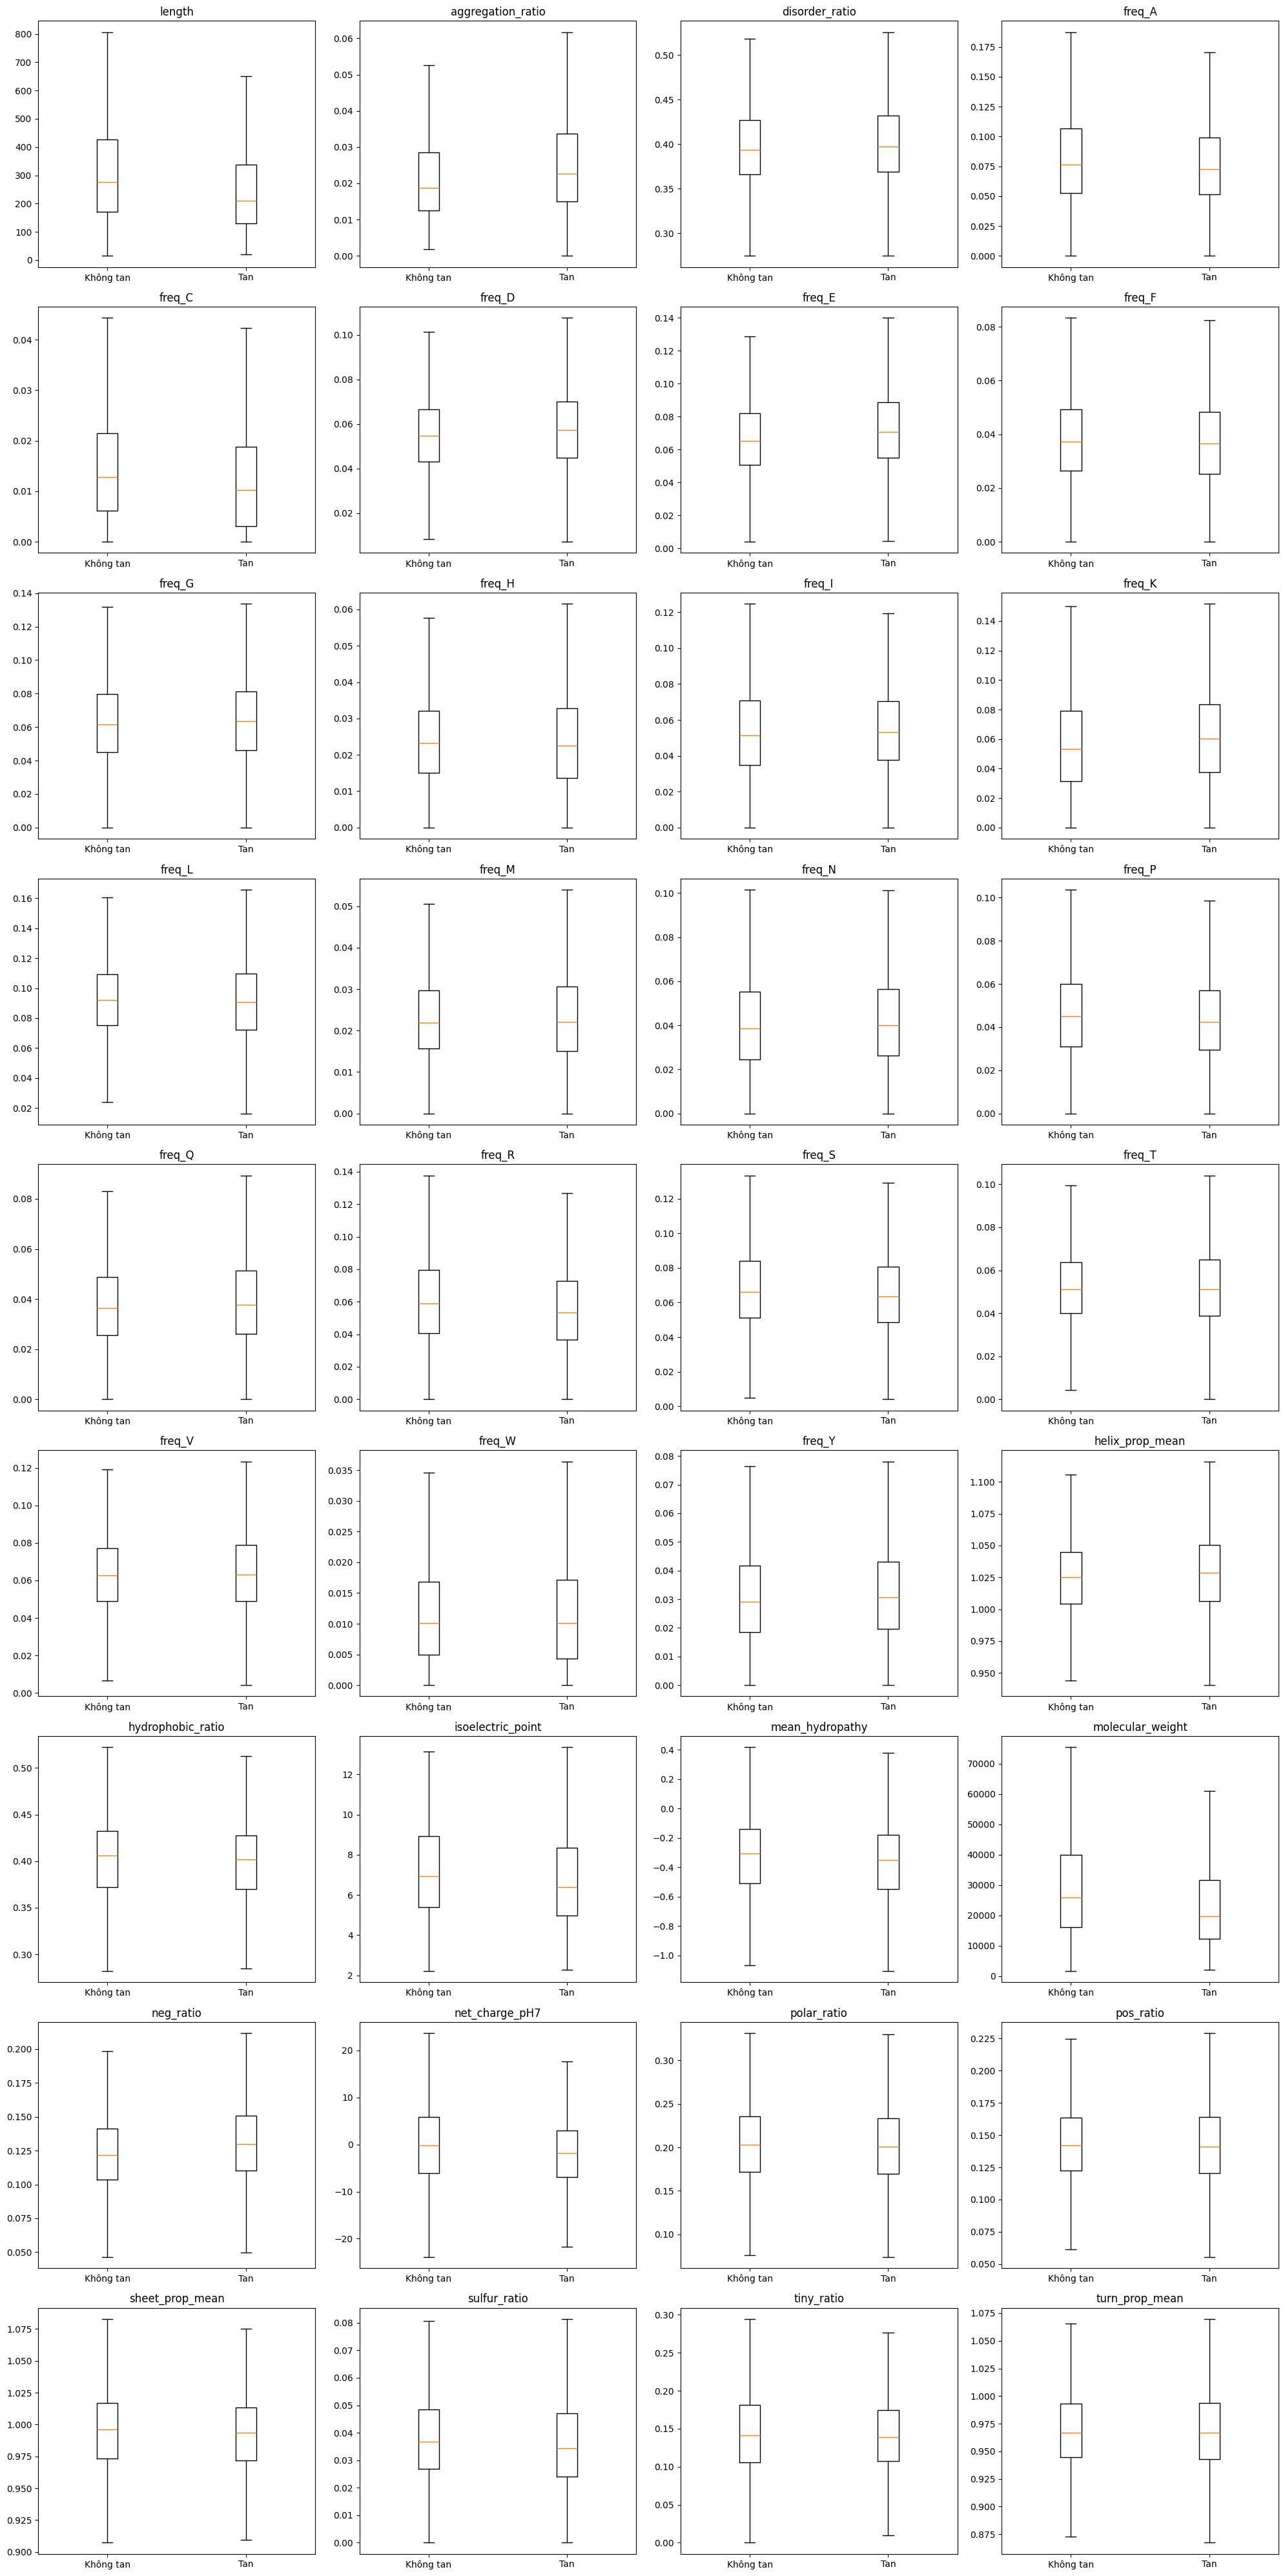

Saved Figure 2: features_36_boxplots_rebuilt.png
Top4 by |delta|: ['length', 'molecular_weight', 'aggregation_ratio', 'neg_ratio']


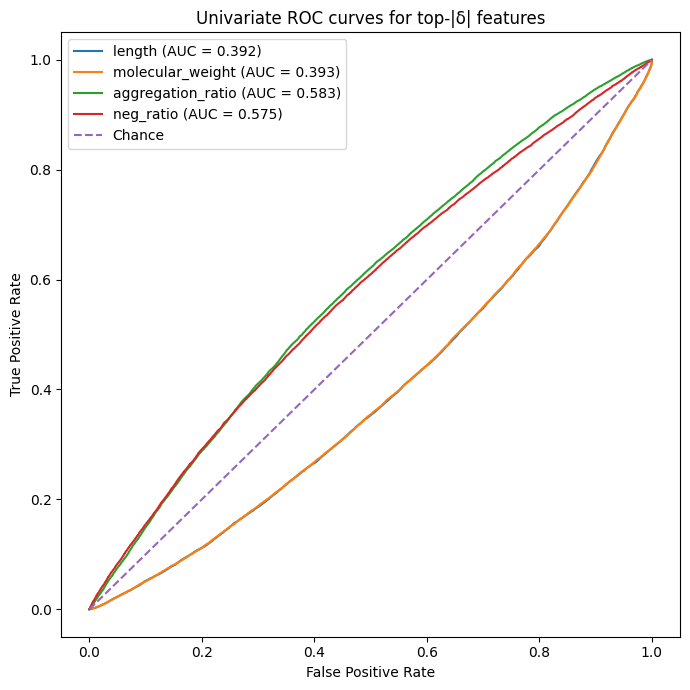

Saved Figure 3: roc_top4_rebuilt.png


In [ ]:
# ============================================================
# BLOCK 3B — VẼ HÌNH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

OUT_FIG2 = "features_36_boxplots.png"
OUT_FIG3 = "roc_top4.png"

# ---------- Figure 2: 36 boxplots ----------
PLOT_ROWS, PLOT_COLS = 9, 4
PLOT_FIGSIZE = (20, 40)

y = df_feat["label"].astype(int).to_numpy()

plot_features = FEATURE_COLS[: (PLOT_ROWS * PLOT_COLS)]

fig, axes = plt.subplots(PLOT_ROWS, PLOT_COLS, figsize=PLOT_FIGSIZE)
axes = axes.flatten()

for ax, fn in zip(axes, plot_features):
    x = df_feat[fn].astype(float).to_numpy()
    neg = x[y == 0]
    pos = x[y == 1]
    ax.boxplot([neg, pos], labels=["Không tan", "Tan"], showfliers=False)
    ax.set_title(fn)

for ax in axes[len(plot_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUT_FIG2, dpi=300)
plt.show()
print("Saved Figure 2:", OUT_FIG2)


# ---------- Figure 3: ROC curves top 4 |delta| ----------
top4 = stats_df.sort_values("abs_delta", ascending=False).head(4)["feature"].tolist()
print("Top4 by |delta|:", top4)

plt.figure(figsize=(7, 7))
for fn in top4:
    scores = df_feat[fn].astype(float).to_numpy()
    auc = roc_auc_score(y, scores)
    fpr, tpr, _ = roc_curve(y, scores)
    plt.plot(fpr, tpr, label=f"{fn} (AUC = {auc:.3f})")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Univariate ROC curves for top-|δ| features")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG3, dpi=300)
plt.show()
print("Saved Figure 3:", OUT_FIG3)

In [ ]:
# ============================================================
# BLOCK 4 — COMPOSITE-δ
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    confusion_matrix
)

OUT_PRED_CSV   = "composite_delta_predictions.csv"
OUT_METRIC_CSV = "composite_delta_metrics.csv"

df = df_feat.copy()

BASE_FEATURES = ["length", "molecular_weight", "aggregation_ratio", "neg_ratio"]
df = df[["header", "label"] + BASE_FEATURES].dropna()

y = df["label"].astype(int).to_numpy()

z_len = (df["length"] - 236.0) / 231.0
z_mw  = (df["molecular_weight"] - 22232.44) / 21548.4275
z_agg = (df["aggregation_ratio"] - 0.020942) / 0.017708
z_neg = (df["neg_ratio"] - 0.126531) / 0.039934

S = (
    -0.215 * z_len
    -0.214 * z_mw
    +0.166 * z_agg
    +0.150 * z_neg
).to_numpy()

THRESHOLD = 0.0
y_pred = (S > THRESHOLD).astype(int)

# ---- Metrics ----
auc = roc_auc_score(y, S)
tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

metrics = {
    "AUC": auc,
    "ACC": accuracy_score(y, y_pred),
    "F1": f1_score(y, y_pred, zero_division=0),
    "MCC": matthews_corrcoef(y, y_pred),
    "Precision": precision_score(y, y_pred, zero_division=0),
    "Sensitivity": recall_score(y, y_pred, zero_division=0),
    "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    "Threshold": THRESHOLD
}

# ---- Save prediction table ----
df_out = df.copy()
df_out["S"] = S
df_out["pred_label"] = y_pred
df_out["pred_text"] = np.where(y_pred == 1, "tan", "không tan")
df_out.to_csv(OUT_PRED_CSV, index=False)

# ---- Save metrics ----
pd.DataFrame([metrics]).to_csv(OUT_METRIC_CSV, index=False)

print("Saved predictions:", OUT_PRED_CSV)
print("Saved metrics:", OUT_METRIC_CSV)

pd.DataFrame([metrics])

=== Composite-δ baseline (Hard-coded formula) ===
Threshold: 0.0
AUC : 0.615308
ACC : 0.580295
F1  : 0.614443
MCC : 0.166207
PREC: 0.677959
SENS: 0.561808
SPEC: 0.607486
Confusion: TN=19185, FP=12396, FN=20354, TP=26096


,label,length,molecular_weight,aggregation_ratio,neg_ratio,S,pred_label,pred_text
0,0,316.0,28478.585,0.018987,0.107595,-0.225941,0,không tan
1,0,180.0,16539.275,0.033333,0.105556,0.146033,1,tan
2,0,128.0,12178.895,0.046875,0.148438,0.525751,1,tan
3,0,114.0,11544.835,0.035088,0.184211,0.568952,1,tan
4,0,221.0,20953.460,0.022624,0.113122,-0.007932,0,không tan


In [9]:
# ============================================================
# BLOCK 5 — NHẬP CHUỖI AA TỪ BÀN PHÍM -> in 4 chỉ số + S + dự đoán
# ============================================================

import re
from typing import Dict

AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
AA_SET = set(AA_LIST)
SET_HYDROPHOBIC = set("AVILMFWY")

AA_MW = {
    'A': 71.08, 'C': 103.14, 'D': 115.09, 'E': 129.12, 'F': 147.18,
    'G': 57.05, 'H': 137.14, 'I': 113.16, 'K': 128.17, 'L': 113.16,
    'M': 131.19, 'N': 114.10, 'P': 97.12,  'Q': 128.13, 'R': 156.19,
    'S': 87.08, 'T': 101.11, 'V': 99.13,  'W': 186.21, 'Y': 163.18
}
WATER_MASS = 18.015

THRESHOLD = 0.0

def clean_seq_user(seq: str) -> str:
    s = re.sub(r"\s+", "", seq).upper()
    return "".join(ch for ch in s if ch in AA_SET)

def molecular_weight(seq: str) -> float:
    L = len(seq)
    return float(sum(AA_MW[a] for a in seq) - WATER_MASS * (L - 1))

def max_hydrophobic_run_ratio(seq: str) -> float:
    L = len(seq)
    max_run = 0
    cur = 0
    for ch in seq:
        if ch in SET_HYDROPHOBIC:
            cur += 1
            max_run = max(max_run, cur)
        else:
            cur = 0
    return float(max_run / L)

def compute_4_features(seq_raw: str) -> Dict[str, float]:
    seq = clean_seq_user(seq_raw)
    L = len(seq)
    if L == 0:
        raise ValueError("Chuỗi không hợp lệ (chỉ nhận 20 amino acid chuẩn).")

    counts = {aa: 0 for aa in AA_LIST}
    for ch in seq:
        counts[ch] += 1

    return {
        "length": float(L),
        "molecular_weight": molecular_weight(seq),
        "aggregation_ratio": max_hydrophobic_run_ratio(seq),
        "neg_ratio": float((counts["D"] + counts["E"]) / L),
    }

def compute_score(feats: Dict[str, float]) -> float:
    z_len = (feats["length"] - 236.0) / 231.0
    z_mw  = (feats["molecular_weight"] - 22232.44) / 21548.4275
    z_agg = (feats["aggregation_ratio"] - 0.020942) / 0.017708
    z_neg = (feats["neg_ratio"] - 0.126531) / 0.039934

    S = (
        -0.215 * z_len
        -0.214 * z_mw
        +0.166 * z_agg
        +0.150 * z_neg
    )
    return float(S)

seq_input = input("Nhập chuỗi amino acid: ")

features = compute_4_features(seq_input)
S = compute_score(features)
pred = 1 if S > THRESHOLD else 0

print("\n=== KẾT QUẢ ===")
for k, v in features.items():
    print(f"{k:>20s}: {v}")

print(f"{'S score':>20s}: {S}")
print(f"{'Prediction':>20s}: {'tan (soluble)' if pred == 1 else 'không tan (insoluble)'}")


=== KẾT QUẢ ===
              length: 316.0
    molecular_weight: 28478.585
   aggregation_ratio: 0.0189873417721519
           neg_ratio: 0.10759493670886076
             S score: -0.22594122337249656
          Prediction: không tan (insoluble)
